# Исследование рынка общественного питания Москвы на лето 2022 года

- Автор: Байжокина Ботагоз

### Цели и задачи проекта

Провести исследовательский анализ рынка заведений общественного питания Москвы на основе данных сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года, чтобы определить перспективные форматы и локации для открытия нового заведения общественного питания.

### Описание данных

Для анализа будет использован датасет с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Данные состоят из двух датасетов:

- `rest_info.csv` - содержит информацию о заведениях общественного питания;
- `rest_price.csv` - содержит информацию о среднем чеке в заведениях общественного питания.

### Описание датасета `rest_info.csv` 

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — `5.0`);
- `chain` — число, выраженное `0` или `1`, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - `0` — заведение не является сетевым;
    - `1` — заведение является сетевым.
- `seats` — количество посадочных мест.

### Описание датасета `rest_price.csv` 

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
        
        и так далее;
        
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.


### Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними

In [4]:
# Импортируем библиотеки
import pandas as pd

# Библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from phik import phik_matrix
    print('phik успешно импортирован')
except ImportError: 
    print('phik не найден, пробуем установить')
    %pip install -U phik
    try:
        from phik import phik_matrix
        print('phik установлен и импортирован')
    except ImportError: 
        print('Не удалось импортировать phik')


phik успешно импортирован


In [5]:
rest_info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [6]:
# Выводим первые строки
rest_info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [7]:
# Выводим информацию о датафрейме
rest_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [8]:
rest_price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [9]:
rest_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк. Он содержит информацию о заведениях общественного питания. 
Выводы после первичного анализа: 
- Наименования столбцов написаны в нижнем регистре, менять ничего не нужно.
- Два столбца содержат пропуски: `hours`, `seats`. Нужно проверить остальные столбцы на наличие значений-индикаторов, которые могут говорить об отсутствии данных. 
- Значения в столбцах, на первый взгляд, соответствуют описанию. 

Типы данных и их корректность: 
- **Числовые значения с плавающей запятой (`float64`)**.
    - `rating` - можно понизить размерность для оптимизации, так как максимально допустимое для него значение 5.0
    - `seats` - можно преобразовать тип данных в `Int8`, если все значения целочисленные, так как данный столбец содержит информацию о количестве посадочных мест. 
 - **Целочисленные значения (`int64`)**. 
    - `chain` - для простоты вычислений, можно оставить целочисленным, понизив размерность 
- **Строковые данные (`object`).**
    - `id`, `name`, `address`, `hours` содержат строковую информацию идентификатора, наименования, адреса и часов работы заведения. Тип корректен. 
    - `category`, `district` тоже содержат строковую информацию, но при ограниченном количестве уникальных значений, можно их рассматривать как категориальные и преобразовать тип данных в `category`


Датасет `rest_price.csv` содержит 5 столбцов и 8058 строк. Он содержит информацию о среднем чеке в заведениях.
Выводы после первичного анализа: 

- Наименования столбцов написаны в змеином регистре, менять ничего не нужно.
- Все столбцы, кроме идентифиактора, содержат пропуски. 
- Значения в столбцах, на первый взгляд, соответствуют описанию. 

Типы данных и их корректность: 
- **Числовые значения с плавающей запятой (`float64`)**.
    - `middle_avg_bill`, `middle_coffee_cup` - содержат числа с оценкой среднего чека и одной чашки каппучино. Можно понизить размерность для оптимизации, маловероятно что данные столбцы будут хранить большие значения.
- **Строковые данные (`object`).**
    - `id`, `avg_bill` содержат строковую информацию идентификатора и диапазон средней стоимости заказа. Тип корректен.
    - `price` так же содержит строковую информацию, но можно рассматривать ее как категориальный признак. 

### Подготовка единого датафрейма

In [10]:
df = pd.merge(rest_info_df, rest_price_df, on = 'id', how='left')
df_init = df.copy()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [12]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


Для создания единого датасета, было использовано левое объединение `rest_info_df` c `rest_price_df`, чтобы сохранить информацию обо всех заведениях, оставив пропуски в столбцах `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` для случаев, когда нет необходимости учитывать данные столбцы в анализе. 

В результате объединения мы видим, что данные `rest_price_df` не были потеряны, количество строк идентично изначальному. Все данные о средних чеках предоставлены только для тех заведений, которые есть в `rest_info_df`.

## 2. Предобработка данных и подготовка к исследовательскому анализу данных

In [13]:
# Cтолбцы chain, seats можно привести в целочисленный тип данных 
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')
df['seats'] = df['seats'].astype('Int16')

# Для столбцов 'rating','middle_avg_bill','middle_coffee_cup' можно уменьшить размерность
for col in ['rating','middle_avg_bill','middle_coffee_cup']:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [14]:
for col in ['category', 'price', 'district']:
    print(f'Уникальные значения {col}: {df[col].nunique()}')
    print(df[col].unique(), '\n')

Уникальные значения category: 8
['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'
 'булочная' 'столовая'] 

Уникальные значения price: 4
[nan 'выше среднего' 'средние' 'высокие' 'низкие'] 

Уникальные значения district: 9
['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административный округ' 'Юго-Восточный административный округ'
 'Южный административный округ' 'Юго-Западный административный округ'] 



In [15]:
# Столбцы 'category','district', 'price' можно привести в тип "category"
for col in ['category','district', 'price']:
    df[col] = df[col].astype('category')

In [16]:
df.dtypes

id                     object
name                   object
category             category
address                object
district             category
hours                  object
rating                float32
chain                    int8
seats                   Int16
price                category
avg_bill               object
middle_avg_bill       float32
middle_coffee_cup     float32
dtype: object

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [17]:
(pd.DataFrame({'Кол-во пропусков': df.isnull().sum(), 'Доля пропусков': df.isnull().mean()*100})
           .sort_values(by='Кол-во пропусков', ascending=False)
           .style.background_gradient(cmap='coolwarm'))

,Кол-во пропусков,Доля пропусков
middle_coffee_cup,7871,93.635498
middle_avg_bill,5257,62.538663
price,5091,60.563883
avg_bill,4590,54.603854
seats,3611,42.957411
hours,536,6.376398
id,0,0.000000
name,0,0.000000
category,0,0.000000
address,0,0.000000


В датафрейме найдены пропуски в 6 столбцах:
- `hours`: 536 строк, это 6% данных. Возможно, график работы заведения не был указан владельцами или отсутствовала в источниках Яндекс Карт/Бизнеса. Можно заменить значением-индикатором. 
- `seats`: 3611 строк, 42.96% данных. Не все заведения указывают количество посадочных мест. Возможно, это маленькие кофейни, киоски, фаст-фуд точки "на вынос" или бары без фиксированных мест. Пропусков слишком много чтобы удалять или заменять средним значением. Можно оставить как есть и работать с непустыми значениями. 
- `price`: 5091 строк, 60.56% данных. В источниках не всегда указывается ценовая категория. Заменить значением-индикаторм `Неизвестно`.
- `avg_bill`: 4590 строк, 54.60% данных. В источниках не всегда указывается средний чек. Можно заменить значением-индикатором, так как строковые столбцы учавствуют только в категориальном анализе и нет необходимости оставлять пропуски.
- `middle_avg_bill`: 5257 строк, 62.54% данных. 
- `middle_coffee_cup`: 7871 строк, 93.64% данных. 

Пропуски в `middle_avg_bill` и `middle_coffee_cup` связаны с отсутсвием информации в столбце `avg_bill`.

В итоге:
1. Категориальные признаки `hours`, `price`, `avg_bill` -> замена на индикатор
2. Числовые признаки `seats`, `middle_avg_bill`, `middle_coffee_cup` -> оставить `NaN` и работать только с непустыми значениями

Можно также рассмотреть корреляцию пропусков. 

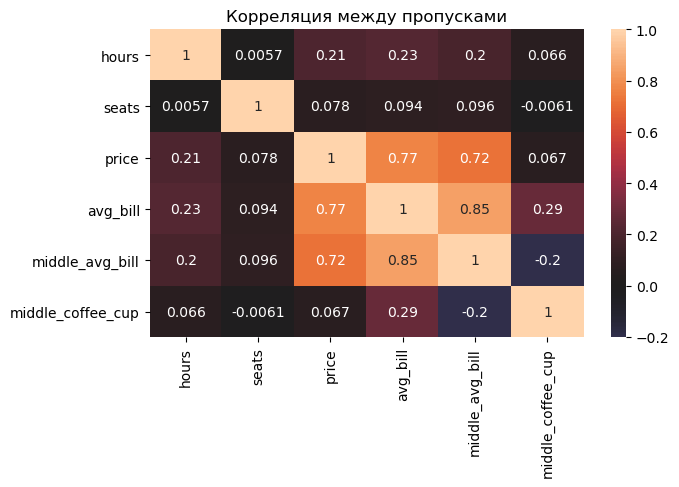

In [18]:
na_matrix = df[['hours', 'seats', 'price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']].isna().astype(int)
corr_na = na_matrix.corr(method='pearson')
plt.figure(figsize=(7, 4))
sns.heatmap(corr_na, annot=True, center=0)
plt.title("Корреляция между пропусками")
plt.show()

Выводы: 
- Ожидаемо можно увидеть сильную корреляцию между `avg_bill` и `middle_avg_bill`. Так как `middle_avg_bill` рассчитывается именно из строк `avg_bill`. 
- `middle_avg_bill` и `middle_coffee_cup` имеют слабую отрицательную корреляцию (-0.2). Это объясняется тем, что оба показателя формируются из столбца `avg_bill`, но содержат разную информацию в зависимости от категории заведения: либо о цене чашки капучино, либо о среднем чеке.
- Сильную корреляцию пропусков можно заметить в столбцах `price`, `avg_bill` и `middle_avg_bill`. Возможно пропуски связаны с тем, что оба показателя заполняются из одного источника и часто отсутствуют одновременно.

In [19]:
for col in ['hours','avg_bill']:
    df[col] = df[col].fillna('не указано')

df['price'] = df['price'].cat.add_categories(['не указано']).fillna('не указано')

In [20]:
df.isna().sum()


id                      0
name                    0
category                0
address                 0
district                0
hours                   0
rating                  0
chain                   0
seats                3611
price                   0
avg_bill                0
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

Пропуски остались только в `seats`, `middle_avg_bill`, `middle_coffee_cup`. 

In [21]:
df.duplicated().sum()

0

В данных нет полных дубликатов строк. Проверим неявные дубликаты.

In [22]:
# Нормализация данных с тектовыми значениями
df['name'] = df['name'].str.lower().str.strip()
df['address'] = df['address'].str.lower().str.strip()
df['district'] = df['district'].str.lower().str.strip()
df['category'] = df['category'].str.lower().str.strip()

In [23]:
duplicated_rows = df.duplicated(subset=['name', 'address']).sum()
print('Кол-во дублирующихся строк:', duplicated_rows.sum())
df[df.duplicated(subset=['name', 'address'])]

Кол-во дублирующихся строк: 4


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 10:00–22:00",3.2,0,<NA>,не указано,не указано,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,не указано,не указано,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,не указано,не указано,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,не указано,4.1,0,276,не указано,не указано,NaN,NaN


In [24]:
# Удаляем дубликаты
df = df.drop_duplicates(subset = ['name', 'address'])

In [25]:
for col in ['category', 'price', 'district', 'chain']:
    print(f'Уникальные значения {col}:')
    print(df[col].unique())
    print()

for col in ['name', 'address']:
    print(f'Уникальных значений {col}:')
    print(df[col].nunique(), '\n')

Уникальные значения category:
['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'
 'булочная' 'столовая']

Уникальные значения price:
['не указано', 'выше среднего', 'средние', 'высокие', 'низкие']
Categories (5, object): ['не указано', 'выше среднего', 'средние', 'высокие', 'низкие']

Уникальные значения district:
['северный административный округ'
 'северо-восточный административный округ'
 'северо-западный административный округ'
 'западный административный округ' 'центральный административный округ'
 'восточный административный округ' 'юго-восточный административный округ'
 'южный административный округ' 'юго-западный административный округ']

Уникальные значения chain:
[0 1]

Уникальных значений name:
5512 

Уникальных значений address:
5752 



* **Создание дополнительных признаков:** создание бинарного столбца `is_24_7` для идентификации заведений, работающих ежедневно и круглосуточно (`True` — для круглосуточных объектов, `False` — для остальных)[cite: 4].

In [26]:
# Функция, которая создает новый столбец с бинарным признаком в зависимости от наличия необходимых значений в другом столбце
def create_is_24_7(x):
    if (x.find('ежедневно') != -1 and x.find('круглосуточно') != -1) or x.find('24/7')!=-1:
        return 1
    else:
        return 0

In [27]:
# Новый столбец 'is_24_7' с помощью функции create_is_24_7
df['is_24_7'] = df['hours'].apply(create_is_24_7)

In [28]:
print('Количество круглосуточных заведений:',df[df['is_24_7']!= 0].shape[0])

Количество круглосуточных заведений: 730


---

### Промежуточный вывод

В результате предобработки данных было сделано:

Типы данных:
- Cтолбцы `chain`, `seats` приведены в целочисленный тип данных
- Для столбцов `rating`, `middle_avg_bill`, `middle_coffee_cup` уменьшена размерность до `float32`
- После проверки уникальных значений и их количества, столбцы `category`, `district`, `price` преобразованы в тип `category`.

Пропуски: 
- Сильная корреляция пропусков была обнаружена в столбцах `price`, `avg_bill` и `middle_avg_bill`
- Пропуски в категориальных признаках `hours`, `price`, `avg_bill` были заменены на значение-индикатор `не указано`
- Пропуски в числовых признаках `seats`, `middle_avg_bill`, `middle_coffee_cup` остались как есть. 

Дубликаты: 
- Явных дубликатов не было обнаружено, но найдено 4 неявных дубликата с одинаковым наимнованием и адресом заведения. 

In [29]:
print('Кол-во строк в исходном датасете: ',df_init.shape[0])
print('Осталось строк в результате обработки пропусков и дубликатов: ', df.shape[0])
print('Удалено строк: ', df_init.shape[0] - df.shape[0])
print('Их доля составляет: ', round(((df_init.shape[0] - df.shape[0]) / df_init.shape[0] *100), 2), '%' )

Кол-во строк в исходном датасете:  8406
Осталось строк в результате обработки пропусков и дубликатов:  8402
Удалено строк:  4
Их доля составляет:  0.05 %


## 3. Исследовательский анализ данных
* Проведение детального исследования исходных датасетов с использованием оптимальных и корректно оформленных визуализаций (с заголовками, подписанными осями, легендами и удобным для восприятия размером).
* Формирование коротких комментариев с выводами и интерпретацией результатов после каждого изученного пункта.
* Итоговое обобщение результатов этапа с выделением наиболее значимых выводов и инсайтов.

### 1. Анализ категорий заведений
Исследование представленных в данных категорий общественного питания и подсчет количества объектов по каждому типу с построением соответствующей визуализации.

In [30]:
print('Количество заведений по категориям')
df['category'].value_counts().sort_values(ascending=False)

Количество заведений по категориям


кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [31]:
print('Доля заведений по категориям')
df['category'].value_counts(normalize=True).sort_values(ascending=False)*100

Доля заведений по категориям


кафе               28.278981
ресторан           24.303737
кофейня            16.817424
бар,паб             9.093073
пиццерия            7.533920
быстрое питание     7.176863
столовая            3.749107
булочная            3.046894
Name: category, dtype: float64

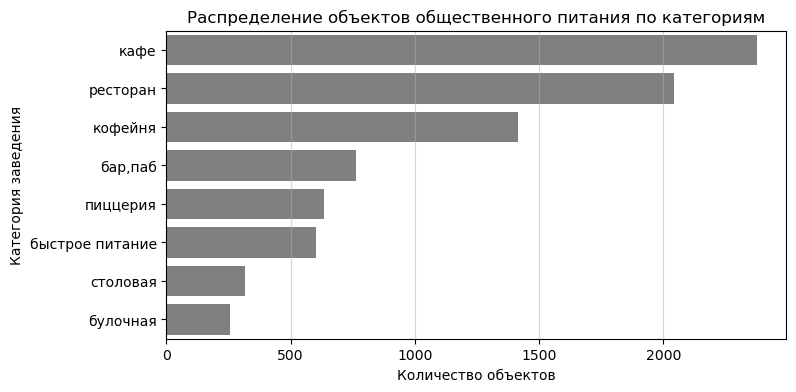

In [32]:
data = df['category'].value_counts().sort_values(ascending=False).reset_index()
data.columns=['category', 'count']
plt.figure(figsize=(8,4))
sns.barplot(
    data=data, 
    x='count', 
    y='category',
    color='gray'
)
plt.title('Распределение объектов общественного питания по категориям')
plt.grid(axis='x', alpha=0.5)
plt.grid(axis='y', visible=False)
plt.xlabel('Количество объектов')
plt.ylabel('Категория заведения')
plt.show()

В данных предоставлены 8 категорий. В Топ-3 категорий по количеству объектов входят кафе, рестораны и кофейни. Категории "Кафе" и "Ресторан" имеют более 2000 заведений. 
Наименее часто встречаются булочные и столовые.

### 2.Анализ географического распределения: 
  * Исследование перечня административных округов Москвы и оценка распределения общего числа заведений по районам.
  * Детальный анализ распределения заведений по каждой отдельной категории внутри Центрального административного округа (ЦАО).
  * Визуализация полученных результатов с подбором оптимальных форматов графиков.

In [33]:
print('Количество заведений по округам')
df['district'].value_counts().sort_values(ascending=False)

Количество заведений по округам


центральный административный округ         2242
северный административный округ             898
южный административный округ                892
северо-восточный административный округ     890
западный административный округ             850
восточный административный округ            798
юго-восточный административный округ        714
юго-западный административный округ         709
северо-западный административный округ      409
Name: district, dtype: int64

In [34]:
print('Доля заведений по округам')
df['district'].value_counts(normalize=True).sort_values(ascending=False)*100

Доля заведений по округам


центральный административный округ         26.684123
северный административный округ            10.687931
южный административный округ               10.616520
северо-восточный административный округ    10.592716
западный административный округ            10.116639
восточный административный округ            9.497739
юго-восточный административный округ        8.497977
юго-западный административный округ         8.438467
северо-западный административный округ      4.867889
Name: district, dtype: float64

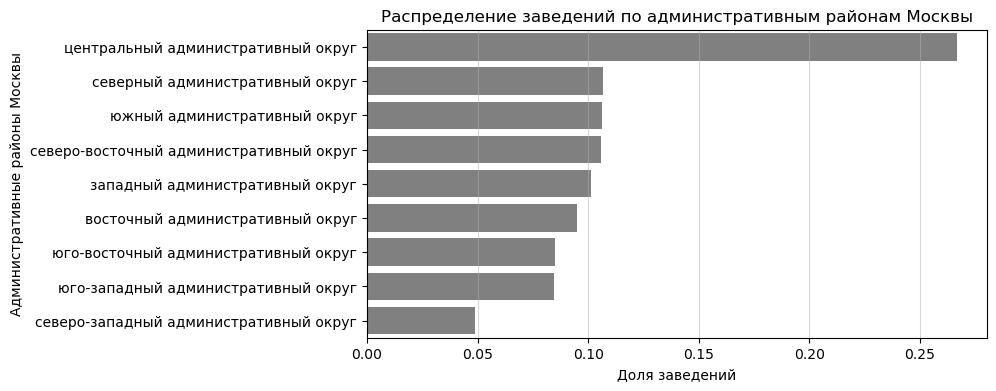

In [102]:
data = df['district'].value_counts(normalize=True).sort_values(ascending=False).reset_index()
data.columns = ['district', 'share']
plt.figure(figsize=(8, 4))
sns.barplot(
    data = data, 
    x='share', 
    y='district', 
    color='gray'
)
plt.grid(axis='x', alpha=0.5)
plt.grid(axis='y', visible=False)
plt.title('Распределение заведений по административным районам Москвы')
plt.xlabel('Доля заведений')
plt.ylabel('Административные районы Москвы')
plt.show()

In [72]:
print('Количество заведений по категориям в Центральном административном округе')
data = df[
    df['district']=='центральный административный округ'
    ]['category'].value_counts().sort_values(ascending=False)
data

Количество заведений по категориям в Центральном административном округе


ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

In [73]:
print('Распределение заведений по категориям в Центральном административном округе')
data = df[
    df['district']=='центральный административный округ'
    ]['category'].value_counts(normalize=True).sort_values(ascending=False)*100
data

Распределение заведений по категориям в Центральном административном округе


ресторан           29.884032
кафе               20.695807
кофейня            19.090098
бар,паб            16.235504
пиццерия            5.040143
быстрое питание     3.880464
столовая            2.943800
булочная            2.230152
Name: category, dtype: float64

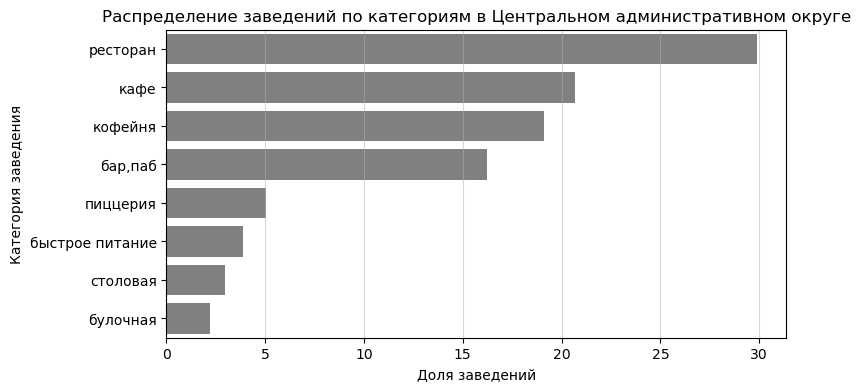

In [74]:
plt.figure(figsize=(8, 4))
data = data.reset_index()
data.columns = ['category', 'share']
sns.barplot(
    data=data,
    x='share',
    y='category', 
    color='gray'
)
plt.grid(axis='x', alpha=0.5)
plt.grid(axis='y', visible=False)
plt.title('Распределение заведений по категориям в Центральном административном округе')
plt.xlabel('Доля заведений')
plt.ylabel('Категория заведения')
plt.show()

В данных присутствуют 9 административных округов Москвы. 
Больше всего заведений находится в ЦАО, они составляют чуть больше четверти от общего количества заведений Москвы. Наиболее популярные категории в данном округе: рестораны(~30%), кафе(~20%) и кофейни(~16%). Реже встречаются булочные, столовые и заведения быстрого питания. Их доля составляет < 5%. В центре любят отдыхать туристы, а еще там много офисов. Так что рестораны вполне ожидаемы. В центре аренда дороже, поэтому логичнее открывать более дорогие заведения.

### 3. Анализ сетевой структуры заведений
  * Исследование соотношения сетевых и несетевых объектов общественного питания в целом по всему массиву данных.
  * Анализ распределения сетевых и несетевых форматов в разрезе отдельных категорий заведений для выявления наиболее склонных к сетевому масштабированию типов бизнеса.
  * Визуализация полученных закономерностей с помощью подходящих графиков.

In [39]:
print("Количество сетевых и несетевых заведений")
df['chain'].value_counts()

Количество сетевых и несетевых заведений


0    5199
1    3203
Name: chain, dtype: int64

In [40]:
print("Распределение сетевых и несетевых заведений")
df['chain'].value_counts(normalize=True)*100

Распределение сетевых и несетевых заведений


0    61.878124
1    38.121876
Name: chain, dtype: float64

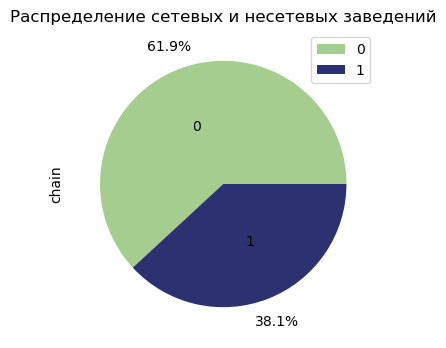

In [41]:
df['chain'].value_counts(normalize=True).plot(
             kind='pie',
             title='Распределение сетевых и несетевых заведений',
             figsize=(7,4),
             cmap = 'crest',
             autopct='%1.1f%%', 
             pctdistance=1.2, 
             labeldistance=.5 
             
)
plt.legend()
plt.show()

In [42]:
print('Распределение сетевых и несетевых заведений по категориям')
df.groupby('category')['chain'].value_counts(normalize=True).unstack(fill_value=0).sort_values(by=1)

Распределение сетевых и несетевых заведений по категориям


chain,0,1
category,,
"бар,паб",0.780105,0.219895
столовая,0.720635,0.279365
кафе,0.672138,0.327862
ресторан,0.642997,0.357003
быстрое питание,0.615257,0.384743
кофейня,0.490446,0.509554
пиццерия,0.478673,0.521327
булочная,0.386719,0.613281


<Figure size 800x400 with 0 Axes>

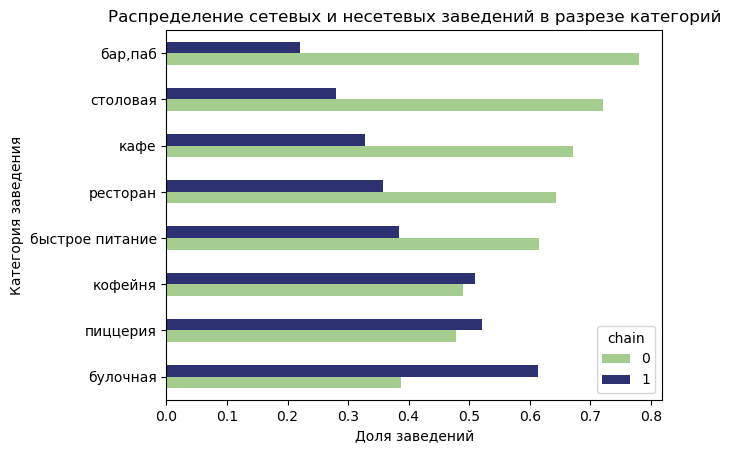

In [75]:
grouped = df.groupby('category')['chain'].value_counts(normalize=True).unstack(fill_value=0).sort_values(by=0)
plt.figure(figsize=(8, 4))

grouped.plot(kind='barh',
             title='Распределение сетевых и несетевых заведений в разрезе категорий',
             cmap='crest')

plt.xlabel('Доля заведений')
plt.ylabel('Категория заведения')
plt.show()

- Доля сетевых заведений составляет около *40%*, тогда как несетевых - *60%* от общего количества. 
- `Булочные`, `пиццерии` и `кофейни` чаще бывают сетевыми. 
- У остальных категорий доля несетевых больше. Категории `бар/паб`, `столовая` и `кафе` чаще бывают несетевыми.

### 4. Анализ посадочных мест и аномалий 
  * Исследование распределения вместимости заведений, выявление выбросов и анализ возможных причин их появления.
  * Определение наиболее типичного (характерного) количества посадочных мест для каждой категории заведений.
  * Визуализация распределения показателей с использованием подходящих графиков.

In [44]:
df['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

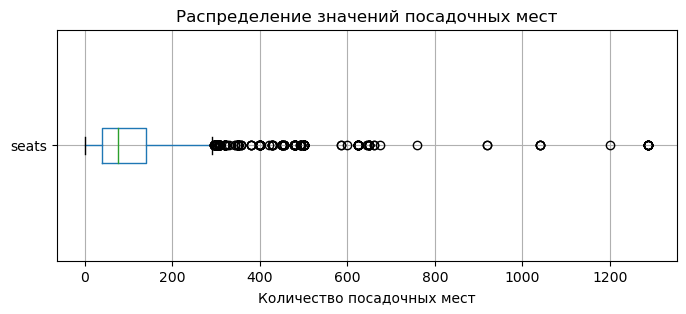

In [77]:
plt.figure(figsize=(8, 3))

df.boxplot(column='seats', vert=False)

plt.title('Распределение значений посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.show()

- Медианное значение количества посадочных мест по всем категориям составляет 75, среднее — 108.36.
- Нижний квартиль равен 40 местам, верхний — 140 местам.
- В данных встречаются заведения с количеством посадочных мест выше ~300. Их можно считать статистическими выбросами, но возможно это просто крупные рестораны, столовые или фудкорты. 
- Есть аномально высокие значения. Чтобы проверить, с чем они связаны, стоит посмотреть сводные таблицы по категориям и округам, а также отдельно проанализировать объекты с более чем 1000 мест.

In [78]:
df[df['seats'] > 300].groupby('category')['seats'].describe().sort_values(by = 'count',
                                                                          ascending=False)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
ресторан,77.0,471.688312,216.182505,305.0,350.00,428.0,500.00,1288.0
кафе,56.0,495.053571,215.472793,306.0,350.00,464.0,521.25,1288.0
кофейня,40.0,494.100000,240.639405,306.0,337.25,375.0,625.00,1288.0
"бар,паб",35.0,510.200000,258.797877,306.0,350.00,420.0,605.00,1288.0
пиццерия,17.0,467.882353,236.853827,320.0,350.00,398.0,455.00,1288.0
быстрое питание,15.0,406.400000,184.646690,306.0,320.00,350.0,400.00,1040.0
столовая,7.0,511.857143,322.315802,310.0,335.00,350.0,526.50,1200.0
булочная,4.0,435.750000,146.511376,320.0,320.00,399.0,514.75,625.0


- У разных категорий заведений встречаются одинаково большие значения, возможно это связано с общим подсчетом мест в ТЦ или ошибкой в данных.
- Медиана кол-ва посадочных мест по категориям всегда меньше среднего и находится в диапазоне 350-460 мест, что более реалистично для больших заведений.
- Больше всего заведений с количеством посадочных мест >300 приходится на рестораны, кафе и кофейни.


In [79]:
df[df['seats'] > 300].groupby('district')['seats'].describe().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
district,,,,,,,,
центральный административный округ,92.0,400.858696,75.119185,306.0,343.0,400.0,480.0,500.0
южный административный округ,47.0,378.829787,68.790899,320.0,320.0,350.0,428.0,675.0
северный административный округ,44.0,491.840909,141.762484,320.0,350.0,625.0,625.0,625.0
западный административный округ,27.0,909.481481,355.267545,478.0,572.5,920.0,1288.0,1288.0
северо-восточный административный округ,17.0,368.000000,64.888366,310.0,350.0,350.0,350.0,500.0
восточный административный округ,13.0,684.461538,277.776774,356.0,420.0,660.0,1040.0,1040.0
юго-западный административный округ,5.0,574.000000,77.868479,491.0,491.0,600.0,644.0,644.0
северо-западный административный округ,3.0,316.666667,5.773503,310.0,315.0,320.0,320.0,320.0
юго-восточный административный округ,3.0,395.000000,98.361578,305.0,342.5,380.0,440.0,500.0


In [80]:
df[df['seats'] > 1000][['name','category','district','address','chain','seats']].sort_values(by='seats').head(10)

,name,category,district,address,chain,seats
2713,ваня и гоги,"бар,паб",восточный административный округ,"москва, измайловское шоссе, 71, корп. а",0,1040
2722,маргарита,быстрое питание,восточный административный округ,"москва, измайловское шоссе, 71, корп. а",1,1040
2770,шоколадница,кофейня,восточный административный округ,"москва, измайловское шоссе, 71, корп. а",1,1040
2966,матрешка,кафе,восточный административный округ,"москва, измайловское шоссе, 71, корп. а",0,1040
4231,рестобар argomento,столовая,западный административный округ,"москва, кутузовский проспект, 41, стр. 1",0,1200
6518,delonixcafe,ресторан,западный административный округ,"москва, проспект вернадского, 94, корп. 1",0,1288
6524,ян примус,ресторан,западный административный округ,"москва, проспект вернадского, 121, корп. 1",1,1288
6574,мюнгер,пиццерия,западный административный округ,"москва, проспект вернадского, 97, корп. 1",1,1288
6641,one price coffee,кофейня,западный административный округ,"москва, проспект вернадского, 84, стр. 1",1,1288
6658,гудбар,"бар,паб",западный административный округ,"москва, проспект вернадского, 97, корп. 1",0,1288


- Аномальные значения (например, 1040 и 1288 мест) сосредоточены только в отдельных округах. Это может быть связано с размещением заведений в крупных ТЦ или фудкортах (часто у них совпадает адрес), либо с технической ошибкой при заполнении данных.
- Больше всего заведений с выбросами — в ЦАО.

In [81]:
df_grouped = df.groupby('category')['seats'].agg(['median', 'mean', 'count']).sort_values(by='median', ascending=False)
df_grouped['share']=round(df_grouped['count']/df_grouped['count'].sum()*100)
df_grouped

,median,mean,count,share
category,,,,
ресторан,86.0,121.892041,1269,26.0
"бар,паб",82.0,124.477516,467,10.0
кофейня,80.0,111.199734,751,16.0
столовая,75.5,99.75,164,3.0
быстрое питание,65.0,98.891117,349,7.0
кафе,60.0,97.365653,1217,25.0
пиццерия,55.0,94.496487,427,9.0
булочная,50.0,89.385135,148,3.0


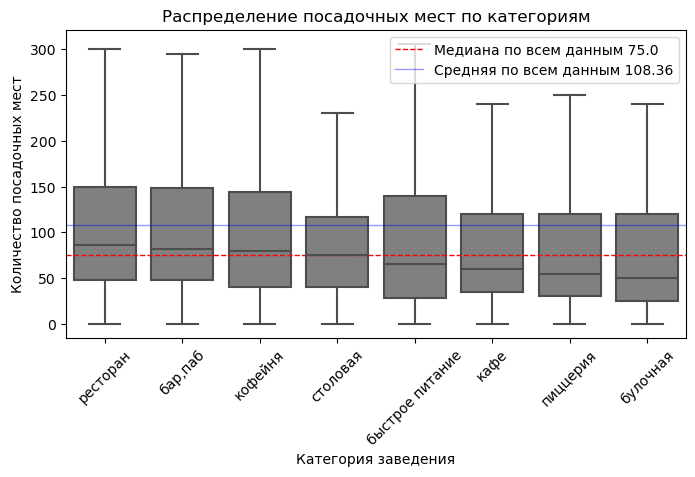

In [82]:
plt.figure(figsize=(8,4))
sns.boxplot(
    data=df, 
    x='category', 
    y='seats', 
    showfliers=False,
    color='grey',
    order=df_grouped.index)
plt.title('Распределение посадочных мест по категориям')
plt.ylabel('Количество посадочных мест')
plt.xlabel('Категория заведения')
plt.xticks(rotation=45)

median_seats = df['seats'].median()
mean_seats = df['seats'].mean()

plt.axhline(median_seats, color='red',
                linestyle='--', linewidth=1,
                label=f'Медиана по всем данным {round(median_seats,2)}')

plt.axhline(mean_seats, color='blue',
                linestyle='-', linewidth=1, alpha=0.4,
                label=f'Средняя по всем данным {round(mean_seats,2)}')
plt.legend(loc=1)
plt.show()

- Во всех категориях заведений медиана ближе к нижней границе диапазона - преобладают компактные заведения. 
- Крупные заведения встречаются реже и формируют правосторонние хвосты распределений.
- Кафе, пиццерии, булочные и заведения быстрого питания чаще всего меньше по размеру, тогда как рестораны, бары и кофейни имеют более крупные типичные значения.

### 5. Анализ пользовательских рейтингов
  * Исследование распределения средних оценок заведений в разрезе их категорий.
  * Оценка степени различия усредненных рейтингов между различными типами предприятий общественного питания.
  * Построение наглядных визуализаций для сравнения полученных распределений.

In [51]:
df['rating'].describe()

count    8402.000000
mean        4.230016
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

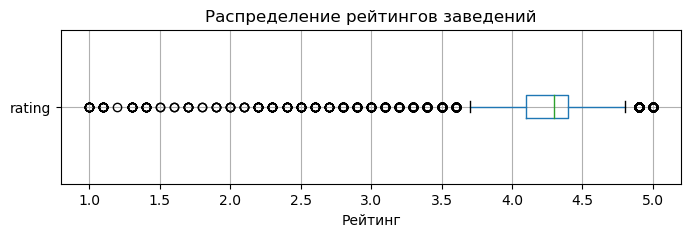

In [83]:
plt.figure(figsize=(8, 2))

df.boxplot(column='rating', vert=False)

plt.title('Распределение рейтингов заведений')
plt.xlabel('Рейтинг')
plt.show()

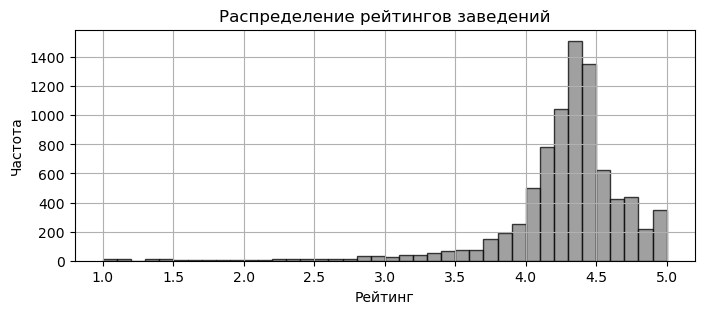

In [84]:
plt.figure(figsize=(8, 3))

df['rating'].plot(
                kind='hist', 
                bins=40, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
                color = 'grey'
)

plt.title('Распределение рейтингов заведений')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')
plt.grid()
plt.show()

In [85]:
data = df.groupby('category')['rating'].describe().sort_values(by='50%', ascending=False)
data['share']=round(data['count']/data['count'].sum()*100,2)
data

,count,mean,std,min,25%,50%,75%,max,share
category,,,,,,,,,
"бар,паб",764.0,4.387697,0.380392,1.1,4.3,4.4,4.6,5.0,9.09
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0,3.05
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0,16.82
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0,7.53
ресторан,2042.0,4.290401,0.413143,1.0,4.2,4.3,4.5,5.0,24.30
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0,3.75
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0,7.18
кафе,2376.0,4.124284,0.566001,1.0,4.0,4.2,4.4,5.0,28.28


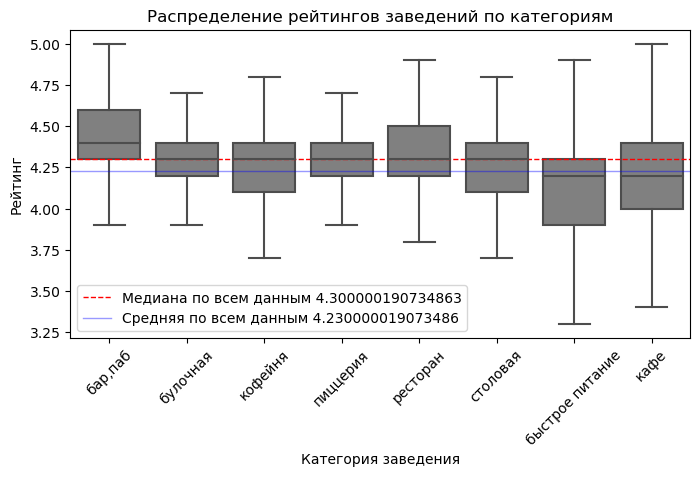

In [86]:
plt.figure(figsize=(8,4))
sns.boxplot(
    data=df, 
    x='category', 
    y='rating', 
    showfliers=False, 
    color='grey', 
    order=data.index
    )
plt.title('Распределение рейтингов заведений по категориям')
plt.xticks(rotation = 45)
plt.xlabel('Категория заведения')
plt.ylabel('Рейтинг')

median_rating = round(df['rating'].median(), 2)
mean_rating = round(df['rating'].mean(), 2)

plt.axhline(median_rating, color='red',
                linestyle='--', linewidth=1,
                label=f'Медиана по всем данным {median_rating}')

plt.axhline(mean_rating, color='blue',
                linestyle='-', linewidth=1, alpha=0.4,
                label=f'Средняя по всем данным {mean_rating}')
plt.legend()
plt.show()

- Распределение рейтингов асимметрично. Редкие низкие оценки оттягивают распределение влево.  Диапазон значений — от 1 до 5, что выглядит корректно. Среднее (4.2) и медиана (4.3) близки друг к другу. 
- Значения ниже ~3.5 можно считать выбросами, но они не являются ошибками и удалять их нет необходимости, так как можно исключить из анализа целую группу заведений с низкой оценкой. 
- Средние и медианы рейтингов по категориям находятся в узком диапазоне 4.0–4.4, существенных различий между типами заведений не наблюдается.
- У булочных и пиццерий наблюдается наименьший разброс рейтингов, тогда как у кафе и заведений быстрого питания диапазон значений заметно шире. Чаще всего высокие оценки получают заведения в категории "бар\паб"

На рынке необходимо сразу удерживать высокий стандарт качества, независимо от формата заведения. Это поможет выделиться среди конкурентов и обеспечить долгосрочную лояльность клиентов.

### 6. Корреляционный анализ рейтингов
  * Построение и визуализация матрицы корреляции рейтинга с ключевыми признаками (категория, административный район, сетевой статус, количество посадочных мест, ценовая категория и круглосуточный режим работы).
  * Выявление наиболее сильной взаимосвязи с рейтингом и ее детальная проверка.

In [87]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category', 'district', 'chain', 'seats', 'price',
                         'is_24_7', 'rating']].phik_matrix(
    interval_cols=['seats', 'rating'] )

print('Корреляционная матрица с коэффициентом phi_k для переменной churn')
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
data_heatmap

Корреляционная матрица с коэффициентом phi_k для переменной churn


,rating
price,0.310473
category,0.198739
district,0.189453
is_24_7,0.161010
chain,0.118857
seats,0.000000


Наибольшая корреляция рэйтинга заведений наблюдается с ценовой категорией (0.31). Для остальных признаков коэффицент снижается с 0.19 до 0. Ниже предоставлена тепловая карта в качестве визуализации. 

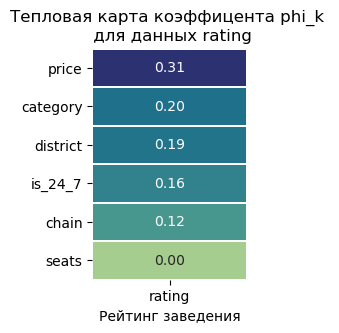

In [88]:
plt.figure(figsize=(2,3))

sns.heatmap(
    data_heatmap,
    annot=True, 
    fmt='.2f', 
    cmap = 'crest', 
    linewidths=0.5, 
    cbar=False
)

plt.title('Тепловая карта коэффицента phi_k \n для данных rating')
plt.xlabel('Рейтинг заведения')
plt.show()

Для проверки наиболее сильной связи `price` и `rating`, построена диаграмма размаха рейтингов для каждой ценовой категории.

In [89]:
data=df.groupby('price')['rating'].describe().sort_values(by='mean', ascending=False)
data

,count,mean,std,min,25%,50%,75%,max
price,,,,,,,,
высокие,478.0,4.436611,0.314197,1.0,4.3,4.4,4.6,5.0
выше среднего,564.0,4.386347,0.223507,2.9,4.3,4.4,4.5,5.0
средние,2117.0,4.297874,0.295653,1.6,4.2,4.3,4.4,5.0
низкие,156.0,4.173077,0.372671,2.6,4.0,4.2,4.4,5.0
не указано,5087.0,4.166778,0.545209,1.0,4.0,4.3,4.4,5.0


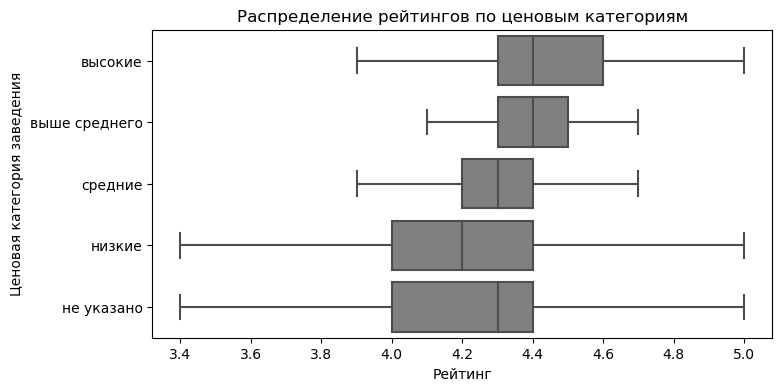

In [90]:
plt.figure(figsize=(8,4))
sns.boxplot(x='rating', 
            y='price', 
            data=df, 
            showfliers = False, 
            color='grey',
            order=data.index)

plt.title("Распределение рейтингов по ценовым категориям")
plt.xlabel('Рейтинг')
plt.ylabel('Ценовая категория заведения')
plt.show()

Зависимость между ценой и рейтингом подтверждается: чем выше ценовая категория, тем чаще заведения получают высокую оценку и наоборот(ожидаемо, но проверить стоило). И медиана, и среднее значение рейтингов повышаются вместе с ростом ценовой категории. 

### 7. Анализ топ-популярных сетей
  * Группировка данных по названиям заведений для определения топ-15 самых распространенных сетей в Москве по количеству точек.
  * Расчет средних рейтингов для выявленных сетей и определение их принадлежности к конкретным категориям общественного питания.
  * Визуализация популярности сетей и сопутствующих метрик с помощью подходящих графиков.

In [91]:
top_15 = df[df['chain'] == 1]['name'].value_counts().sort_values(ascending=False).head(15)

top_15_grouped = df[df['name'].isin(top_15.index)].groupby('name').agg(
    count = ('id', 'count'),
    rating_mean =('rating','mean'),
    category = ('category','first')
).sort_values(by='count', ascending=False).reset_index()
top_15_grouped['share']=round(top_15_grouped['count']/top_15_grouped['count'].sum()*100,2)
print('Сводная таблица ТОП-15 популярных сетей в Москве')
top_15_grouped 

Сводная таблица ТОП-15 популярных сетей в Москве


,name,count,rating_mean,category,share
0,шоколадница,120,4.177500,кофейня,14.67
1,домино'с пицца,77,4.171429,пиццерия,9.41
2,додо пицца,74,4.286487,пиццерия,9.05
3,one price coffee,72,4.069445,кофейня,8.80
4,яндекс лавка,69,3.872464,ресторан,8.44
5,cofix,65,4.075385,кофейня,7.95
6,prime,50,4.116000,ресторан,6.11
7,хинкальная,44,4.322727,быстрое питание,5.38
8,кофепорт,42,4.147619,кофейня,5.13
9,кулинарная лавка братьев караваевых,39,4.394872,кафе,4.77


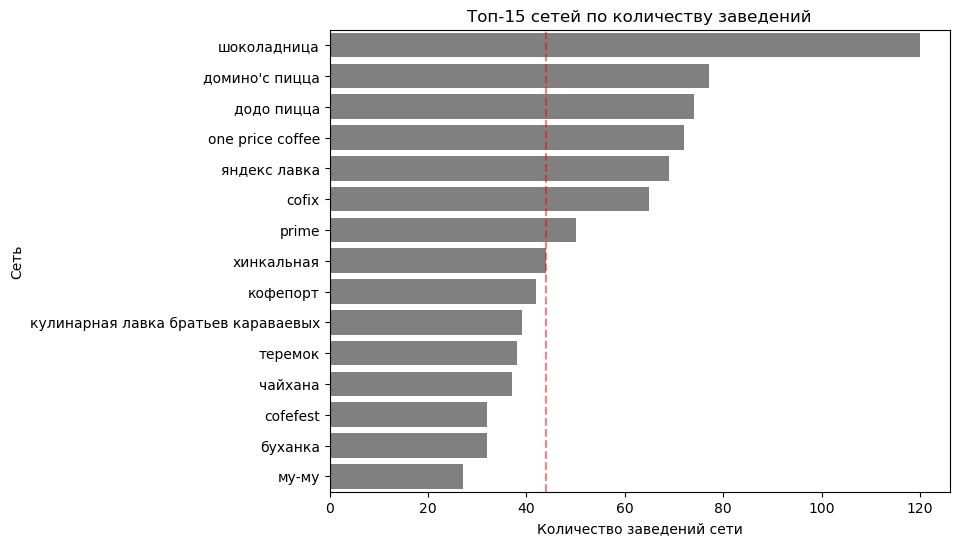

In [93]:
plt.figure(figsize=(8,6))
sns.barplot(
    x='count', 
    y='name', 
    data=top_15_grouped.sort_values(by='count', ascending=False), 
    color='grey'
    )

chain_median = top_15_grouped['count'].median()

plt.axvline(
    x=chain_median,
    alpha=0.5, 
    color='red',
    linestyle='--'
)
plt.title("Топ-15 сетей по количеству заведений")
plt.xlabel("Количество заведений сети")
plt.ylabel("Сеть")
plt.show()

- Количество заведений в ТОП-15 сетей варьируется в диапазоне от 27 до 120.
- Самая популярная сеть - "Шоколадница" (120 заведений).
- Медианное значение кол-ва заведений в сети ~43

In [94]:
top_categories = df[df['name'].isin(top_15.index)].groupby('category').agg(
    count = ('id','count'),
    rating_mean = ('rating','mean')
).reset_index().sort_values(by='count', ascending=False)
top_categories['share']=round(top_categories['count']/top_categories['count'].sum()*100,2)
top_categories

,category,count,rating_mean,share
4,кофейня,337,4.116024,41.20
6,ресторан,186,4.025806,22.74
5,пиццерия,152,4.228290,18.58
3,кафе,100,4.241000,12.22
1,булочная,25,4.416000,3.06
2,быстрое питание,12,4.341667,1.47
0,"бар,паб",4,4.325000,0.49
7,столовая,2,4.100000,0.24


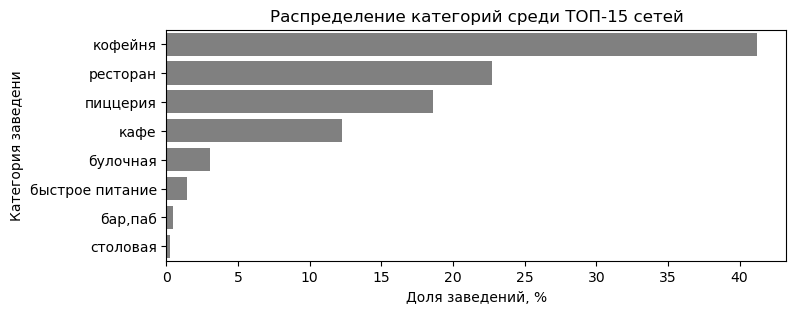

In [95]:
plt.figure(figsize=(8,3))
sns.barplot(
    x='share',
    y='category',
    data=top_categories,
    color='grey'
)
plt.title('Распределение категорий среди ТОП-15 сетей')
plt.xlabel('Доля заведений, %')
plt.ylabel('Категория заведени')
plt.show()


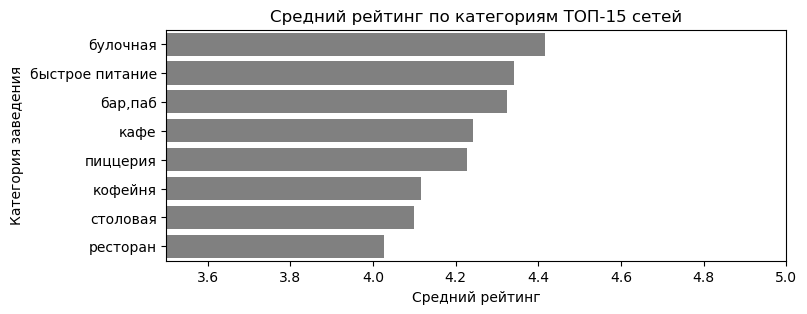

In [96]:
plt.figure(figsize=(8,3))
sns.barplot(
    x='rating_mean', 
    y='category', 
    data=top_categories.sort_values(by='rating_mean', ascending=False), 
    color="grey"
    )
plt.title("Средний рейтинг по категориям ТОП-15 сетей")
plt.xlabel("Средний рейтинг")
plt.ylabel("Категория заведения")
plt.xlim(3.5,5)
plt.show()

In [97]:
r = top_categories['count'].corr(top_categories['rating_mean'], method='pearson')
round(r, 2)

-0.58

- Больше всего заведений приходится на `кофейни` (41%). `Рестораны` занимают второе место (~23%), `пиццерии` (~19%). Категории `булочные`, `бар/паб`, `столовые` и `быстрое питание` встречаются редко.
- Самые высокие средние рейтинги у булочных и заведений быстрого питания (~4.3–4.4)
- Рестораны имеют самую низкую среднюю оценку (~4.0) 
- Разница между рейтингами категорий небольшая, но тенденция заметна: менее распространённые категории получают более высокие оценки. Между количеством заведений и средним рейтингом категорий наблюдается умеренная отрицательная корреляция. 


### 8. Анализ среднего чека и влияния локации

  * Исследование вариации среднего чека (`middle_avg_bill`) заведений в зависимости от административного района Москвы.
  * Анализ и сравнение ценовой политики в Центральном административном округе (ЦАО) и остальных районах для выявления характера влияния удаленности от центра на цены.
  * Визуализация распределения ценовых показателей с помощью подходящих графиков.

In [98]:
df['middle_avg_bill'].describe(percentiles=[0.5, 0.6, 0.7, 0.8, 0.95, 0.99])

count     3149.000000
mean       958.053650
std       1009.732849
min          0.000000
50%        750.000000
60%       1000.000000
70%       1200.000000
80%       1470.000000
95%       2250.000000
99%       3750.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

Можно заметить сильно большую разницу между 99% и максимальным значением, что говорит об аномальных выбросах в данных. Для того, чтобы изучить вариацию среднего чека, можно их отфильтровать. 

In [99]:
# Отфильтруем аномальные значения 
df_filtered = df[df['middle_avg_bill'] < df['middle_avg_bill'].quantile(0.99)]

# Теперь группируем по округам
df_grouped = df_filtered.groupby('district')['middle_avg_bill'].describe().sort_values(
    by='mean', 
    ascending=False
    ).reset_index()
df_grouped['share']=df_grouped['count']/df_grouped['count'].sum()*100
df_grouped

,district,count,mean,std,min,25%,50%,75%,max,share
0,центральный административный округ,1037.0,1107.300903,718.654785,0.0,475.0,1000.0,1500.0,3500.0,33.322622
1,западный административный округ,301.0,1002.614624,673.808533,50.0,425.0,950.0,1400.0,3500.0,9.672237
2,северный административный округ,319.0,873.206909,657.149475,130.0,350.0,650.0,1250.0,3500.0,10.250643
3,северо-западный административный округ,157.0,822.222900,595.055237,120.0,340.0,700.0,1100.0,2900.0,5.044987
4,юго-западный административный округ,235.0,792.561707,559.173096,100.0,350.0,600.0,1100.0,2750.0,7.551414
5,восточный административный округ,258.0,766.910828,560.098572,50.0,336.0,550.0,1057.5,3000.0,8.290488
6,южный административный округ,313.0,725.242798,542.500427,100.0,350.0,500.0,1000.0,3500.0,10.057841
7,северо-восточный административный округ,299.0,693.812683,521.985596,50.0,325.0,500.0,925.0,3250.0,9.607969
8,юго-восточный административный округ,193.0,638.057007,522.289429,30.0,275.0,450.0,850.0,3000.0,6.201799


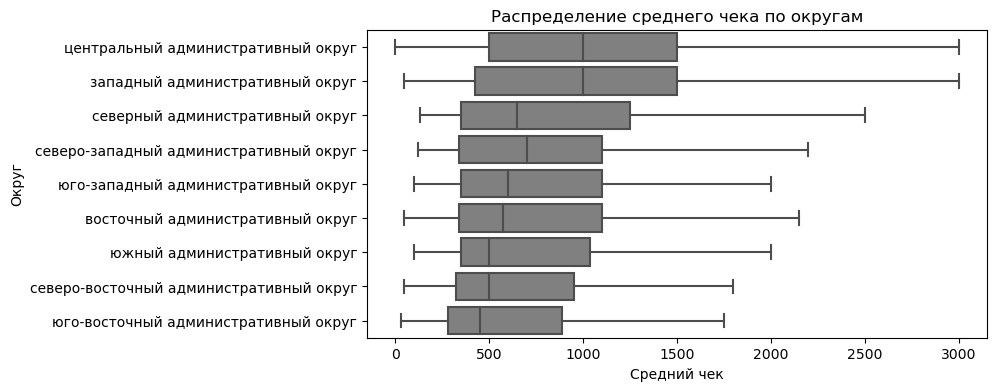

In [100]:
plt.figure(figsize=(8,4))
sns.boxplot(
    x='middle_avg_bill', 
    y='district', 
    data=df, 
    showfliers=False,
    color='grey',
    order=df_grouped['district'])
plt.title("Распределение среднего чека по округам")
plt.xlabel("Средний чек")
plt.ylabel("Округ")
plt.show()

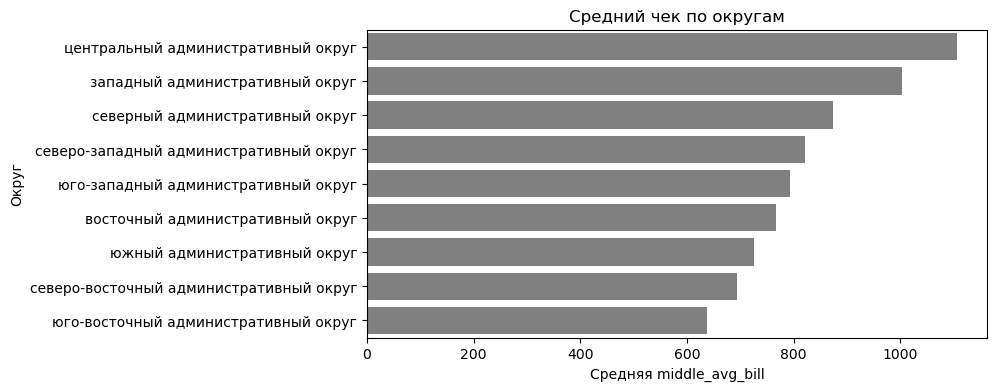

In [101]:
plt.figure(figsize=(8,4))
sns.barplot(x='mean', y='district', data=df_grouped, color='grey')
plt.title('Средний чек по округам')
plt.ylabel('Округ')
plt.xlabel('Средняя middle_avg_bill')
plt.show()

- В ЦАО средний чек самый высокий, при этом разброс цен также максимальный.
- На втором месте — ЗАО: медиана совпадает с ЦАО и составляет около 1000 руб.
- В более удалённых округах медиана постепенно снижается, в ЮВАО и СВАО она находится в пределах 450–500 руб.

---

### Промежуточный вывод

Рынок общественного питания Москвы в основном представлен кафе, ресторанами и кофейнями. Более редкие форматы, такие как булочные, пиццерии и заведения быстрого питания, занимают меньшую долю, но часто получают высокие оценки и могут быть перспективными для развития сетей.

Центральный округ остаётся самым насыщенным по количеству заведений и отличается самым высоким средним чеком (медиана около 1000 рублей), что связано с конкуренцией и разнообразием форматов. В южных и восточных округах медиана среднего чека ниже (450–500 рублей), что указывает на больший спрос на доступные и компактные заведения.

Около 60% заведений несетевые, но кофейни, булочные и пиццерии чаще развиваются именно в сетевом формате, что делает их удобными для масштабирования. Типичное количество посадочных мест — около 75, крупные форматы встречаются редко.

Рейтинги у всех категорий стабильно высокие (4.0–4.4). При этом более дорогие заведения чаще получают лучшие оценки, что подтверждается умеренной положительной корреляцией с ценовой категорией (r = 0.31). Среди крупнейших сетей лидируют "Шоколадница", "Додо Пицца" и "Домино'с", но более высокие средние рейтинги чаще встречаются у менее распространённых форматов.

## 4. Итоговый вывод и рекомендации

### 1. Общий обзор проделанной работы.

В проекте были объединены и проанализированы данные сервисов Яндекс Карты и Яндекс Бизнес о заведениях общественного питания Москвы за лето 2022 года. Всего было рассмотрено 8406 строк данных. В ходе анализа была проделана предобработка данных, были изучены категории заведений, их распределение по округам, соотношение сетевых и несетевых форматов, количество посадочных мест и аномальные значения, распределение рейтингов и их взаимосвязь с другими признаками, популярность сетей и особенности среднего чека по районам Москвы.

### 2. Ответы на исследовательские вопросы, или главные выводы.

- Категории заведений: в данных представлены 8 типов заведений. Чаще всего встречаются кафе, рестораны и кофейни, реже — булочные и столовые.

- Локация: наибольшая концентрация заведений — в ЦАО (чуть больше четверти всех объектов). В этом округе доминируют рестораны, кафе и кофейни.

- Сетевые vs несетевые: около 60% заведений несетевые. Наиболее «сетевые» категории — булочные, пиццерии и кофейни.

- Посадочные места: типичные значения для разных категорий находятся в диапазоне 50-120 мест. Большие аномальные значения (1000+) встречаются редко и связаны либо с количеством посадочных мест в ТЦ, либо с ошибками в заполнении данных.

- Рейтинги: распределение скошено влево, но среднее (4.2) и медиана (4.3) близки. Разброс по категориям небольшой (4.0–4.4), при этом бары получают чуть более высокие оценки. Наиболее стабильные оценки у пиццерий и булочных. 

- Корреляция рейтинга: сильнее всего рейтинг связан с ценовой категорией (r=0.31). Чем выше ценовая категория, тем чаще заведения получают высокие оценки.

- Топ-15 сетей: по популярности лидирует «Шоколадница» (120 заведений). Большинство популярных сетей — кофейни и пиццерии. Булочные и заведения быстрого питания имеют самые высокие средние рейтинги. Между числом заведений и рейтингом есть умеренная отрицательная корреляция: менее распространённые категории получают более высокие оценки. 

- Средний чек: в ЦАО он самый высокий и вариативный (медиана ~1000 руб.), затем идёт ЗАО. Медианные значения чека снижаются по мере смещения от центра к южным и восточным округам (до ~450–500 руб). 

### 3. Рекомендации на основе анализа данных.

- ЦАО подходит для заведений с высоким чеком и разнообразными форматами, но конкуренция будет выше. В южных и восточных округах перспективнее развивать доступные форматы с меньшей вместимостью. 

- Перспективно развивать булочные и бар/пабы — они реже представлены, но показывают высокие оценки пользователей. Булочные хорошо подходят для сетевого развития. Бары и пабы можно рассматривать для точечных проектов с акцентом на качество и атмосферу.

- Данные показывают, что рост числа точек часто сопровождается снижением среднего рейтинга. При масштабировании сетей важно следить за стабильностью уровня обслуживания и впечатлений гостей.
